Dataset: CIFAR‑10, first 200 images, auto‑downloaded, 80–20 split.

SRCNN Model:

conv1: Extracts features.

conv2: Learns non‑linear mapping.

conv3: Reconstructs high‑resolution output.

Training Data:

Downscale images → simulate low‑resolution.

Upsample back to 32×32 → input for model.

Model learns to restore details.

Loss: MSELoss → compares output with original high‑res.

Training: 5 epochs only.

Visualization:

Row 1: Original images

Row 2: Low‑Res inputs

Row 3: Super‑Resolved outputs

Epoch 1, Loss: 0.0632
Epoch 2, Loss: 0.0197
Epoch 3, Loss: 0.0109
Epoch 4, Loss: 0.0080


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0347198..1.0847476].


Epoch 5, Loss: 0.0069
Training complete!


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1341434..1.1026062].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.013176554..1.0185568].


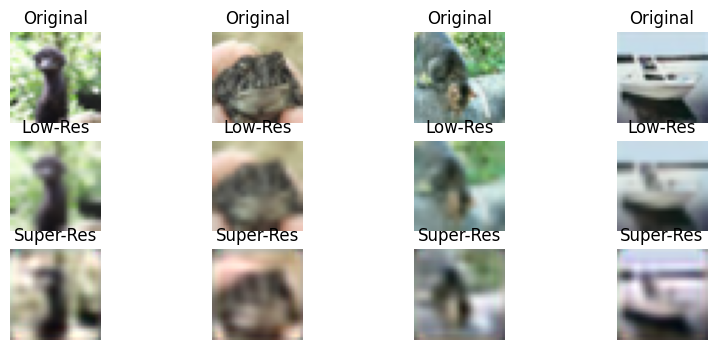

In [1]:
"""
Experiment 6: Super Resolution using Python & PyTorch
------------------------------------------------------
This program demonstrates a simple Super Resolution CNN (SRCNN)
that improves the resolution of low-quality images.
Dataset: CIFAR-10 (200 images, auto-downloaded, 80-20 split).
"""

# Step 1: Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Step 2: Define a simple Super Resolution CNN
class SRCNN(nn.Module):
    def __init__(self):
        super(SRCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=9, padding=4)
        self.conv2 = nn.Conv2d(64, 32, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(32, 3, kernel_size=5, padding=2)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.conv3(x)
        return x

# Step 3: Load CIFAR-10 dataset (200 samples only)
transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])
full_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
subset_indices = list(range(200))  # pick first 200 samples
small_dataset = Subset(full_dataset, subset_indices)

# 80-20 split
train_size = int(0.8 * len(small_dataset))
test_size = len(small_dataset) - train_size
train_set, test_set = random_split(small_dataset, [train_size, test_size])

trainloader = DataLoader(train_set, batch_size=8, shuffle=True)
testloader = DataLoader(test_set, batch_size=8, shuffle=False)

# Step 4: Initialize model, loss, optimizer
model = SRCNN()
criterion = nn.MSELoss()  # pixel-wise loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Step 5: Training loop (5 epochs)
for epoch in range(5):
    model.train()
    running_loss = 0.0
    for images, _ in trainloader:
        # Downscale images to create low-resolution inputs
        low_res = F.interpolate(images, scale_factor=0.5, mode='bilinear')
        low_res_up = F.interpolate(low_res, size=(32,32), mode='bilinear')

        optimizer.zero_grad()
        outputs = model(low_res_up)
        loss = criterion(outputs, images)  # compare with original high-res
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}")

print("Training complete!")

# Step 6: Evaluate and visualize
model.eval()
images, _ = next(iter(testloader))
low_res = F.interpolate(images, scale_factor=0.5, mode='bilinear')
low_res_up = F.interpolate(low_res, size=(32,32), mode='bilinear')

with torch.no_grad():
    outputs = model(low_res_up)

# Plot original, low-res, and super-res
plt.figure(figsize=(10,4))
for i in range(4):
    plt.subplot(3,4,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(3,4,i+5)
    plt.imshow(low_res_up[i].permute(1,2,0))
    plt.title("Low-Res")
    plt.axis("off")

    plt.subplot(3,4,i+9)
    plt.imshow(outputs[i].permute(1,2,0))
    plt.title("Super-Res")
    plt.axis("off")
plt.show()
